In [1]:
# import python libraries

import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib

In [55]:
# some values used for calculations

k = 8.61733e-5 # boltzmann constant in eV/K
TK = 500+273 # equilibrium temp in K
TC = TK-273 # equilibrium temp in C
TQK = 800+273 # quenched temp in K
TQC = TQK-273 # quenched temp in C
a = np.logspace(-20,5,200) # oxygen partial pressure range
print(f'a[154] = {a[154]:.5} atm') # pO2~0.21 atm

a[154] = 0.22219 atm


In [56]:
# Equilibrium defect reaction constants

Ki = 8.55E44*np.exp(-2.91/(k*TK)) # Nowotny and Rekas
KiQ = 8.55E44*np.exp(-2.91/(k*TQK))
KR = 1.06E71*np.exp(-5.69/(k*TK)) # Nowotny and Rekas
# KRQ = 1.06E71*np.exp(-5.69/(k*TQK))
KS = 3.4E105*np.exp(-2.795/(k*TK)) # Nowotny and Rekas

# Lee, Soonil, Clive A. Randall, and Zi‐Kui Liu. "Comprehensive Linkage of Defect and Phase Equilibria through Ferroelectric Transition Behavior in BaTiO3‐Based Dielectrics: Part 1. Defect Energies Under Ambient Air Conditions." Journal of the American Ceramic Society 91, no. 6 (2008): 1748-1752.
# KPSB = (1.55E22)**2*np.exp(10.15)*np.exp(-2.32/(k*TK)) # partial Schottky reaction on Ti-rich side
# KFST = (1.55E22)**5*np.exp(10)*np.exp(-3.33/(k*TK)) # Full Schottky reaction on Ti-rich side

# Hagemann, H‐J., and D. Hennings. "Reversible weight change of acceptor‐doped BaTiO3." Journal of the American Ceramic Society 64, no. 10 (1981): 590-594.
# KMn43 = 2*2.0E22*np.exp(-(3.12-1.28)/(k*TK))
# KMn43Q = 2*2.0E22*np.exp(-(3.12-1.28)/(k*TQK))
# KMn32 = 1/2*2.0E22*np.exp(-(3.12-1.87)/(k*TK))
# KMn32Q = 1/2*2.0E22*np.exp(-(3.12-1.87)/(k*TQK))

print(
    f'at T = {TC} \u00B0C\n'
    f'KS = {KS:.2e}\n'
    # f'KFST = {KFST:.2e}\n'
    # f'KPSB = {KPSB:.2e}\n'
    f'Ki = {Ki:.2e}\n'
    f'KiQ = {KiQ:.2e}\n'
    f'KR = {KR:.2e}\n'
    # f'KMn43 = {KMn43:.2e}\n'
    # f'KMn43Q = {KMn43Q:.2e}\n'
    # f'KMn32 = {KMn32:.2e}\n'
    # f'KMn32Q = {KMn32Q:.2e}'
)


at T = 500 °C
KS = 2.04e+87
Ki = 9.11e+25
KiQ = 1.84e+31
KR = 8.47e+33



In [4]:
# empty lists for each defect concentration; will be filled later
# undoped & A/B = 1.000 / 0.999 / 0.994 & high T eq / low T quenched

CVO2_un_1000e = np.zeros(len(a))
CVO2_un_1000q = np.zeros(len(a))
CVO2_un_999e = np.zeros(len(a))
CVO2_un_999q = np.zeros(len(a))
CVO2_un_994e = np.zeros(len(a))
CVO2_un_994q = np.zeros(len(a))

CVTi4_un_1000e = np.zeros(len(a))
CVTi4_un_1000q = np.zeros(len(a))
CVTi4_un_999e = np.zeros(len(a))
CVTi4_un_999q = np.zeros(len(a))
CVTi4_un_994e = np.zeros(len(a))
CVTi4_un_994q = np.zeros(len(a))

CVBa2_un_1000e = np.zeros(len(a))
CVBa2_un_1000q = np.zeros(len(a))
CVBa2_un_999e = np.zeros(len(a))
CVBa2_un_999q = np.zeros(len(a))
CVBa2_un_994e = np.zeros(len(a))
CVBa2_un_994q = np.zeros(len(a))

n_un_1000e = np.zeros(len(a))
n_un_1000q = np.zeros(len(a))
n_un_999e = np.zeros(len(a))
n_un_999q = np.zeros(len(a))
n_un_994e = np.zeros(len(a))
n_un_994q = np.zeros(len(a))

p_un_1000e = np.zeros(len(a))
p_un_1000q = np.zeros(len(a))
p_un_999e = np.zeros(len(a))
p_un_999q = np.zeros(len(a))
p_un_994e = np.zeros(len(a))
p_un_994q = np.zeros(len(a))

undoped & A/B = 1.0 & T = 500 °C
at pO2 ~ 0.21 atm
n = 2.18e+08
p = 4.17e+17
[VO2+] = 3.77e+17
[VBa2-] = 1.95e+17
[VTi4-] = 1.95e+17


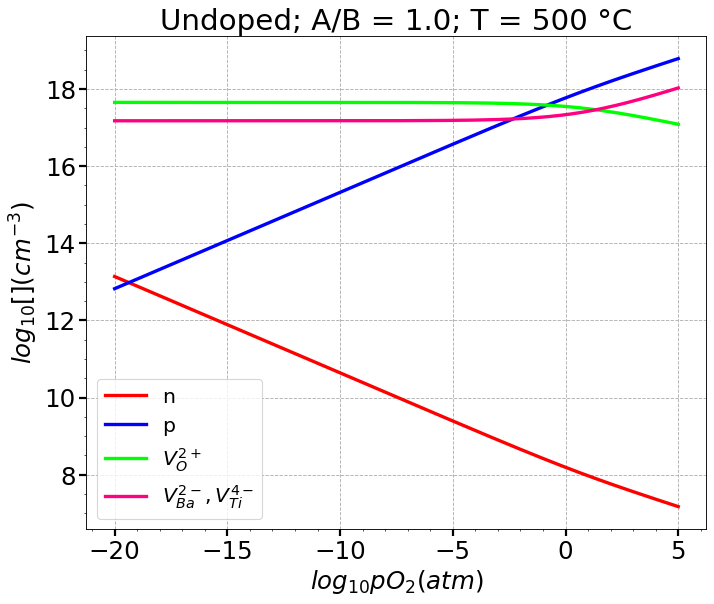

In [58]:
"""
[1] undoped & A/B = 1.000 & high T eq

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""
ratio = 1.000

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 6*(KS/(KR**3))**(1/2)*(x**3)*(y**(3/4)) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1,1E30, maxiter=200)
    
    n_un_1000e[i] = np.array(sol1).astype(np.float64)
    p_un_1000e[i] = Ki/n_un_1000e[i]
    CVO2_un_1000e[i] = KR/((n_un_1000e[i]**2)*(y**(1/2)))
    CVTi4_un_1000e[i] = (KS/(KR**3))**(1/2)*(n_un_1000e[i]**3)*(y**(3/4))
    CVBa2_un_1000e[i] = CVTi4_un_1000e[i]

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Undoped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_un_1000e),c =[255/255, 0/255, 0/255], label=r'n', linewidth=3)
ax1.plot(np.log10(a),np.log10(p_un_1000e), c =[0/255, 0/255, 255/255], label = r'p', linewidth=3)
ax1.plot(np.log10(a),np.log10(CVO2_un_1000e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$', linewidth=3)
ax1.plot(np.log10(a),np.log10(CVBa2_un_1000e), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}, V_{Ti}^{4-}$', linewidth=3)
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
# ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'undoped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_un_1000e[154]:.2e}\n'
    f'p = {p_un_1000e[154]:.2e}\n'
    f'[VO2+] = {CVO2_un_1000e[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_un_1000e[154]:.2e}\n'
    f'[VTi4-] = {CVTi4_un_1000e[154]:.2e}'
)

undoped & A/B = 0.999 & T = 1150 °C
at pO2 ~ 0.21 atm
n = 8.71e+15
p = 4.85e+18
[VO2+] = 2.09e+19
[VBa2-] = 1.81e+19
[VTi4-] = 2.60e+18


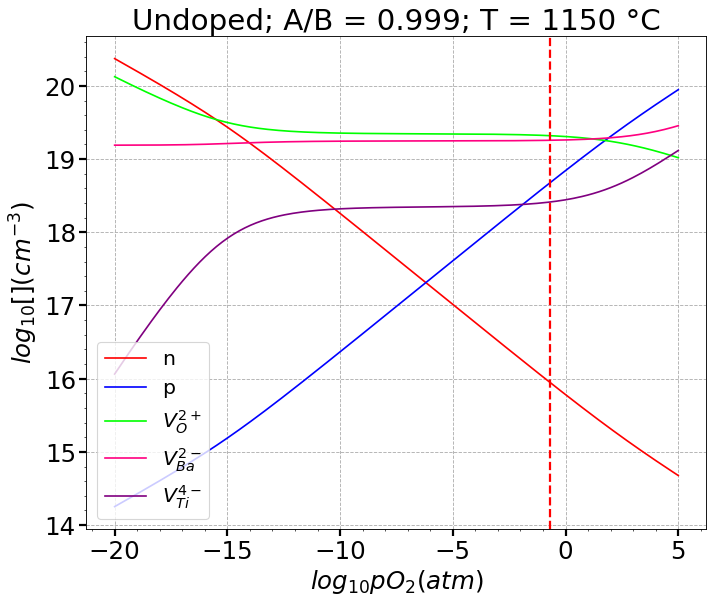

In [6]:
"""
[2] undoped & A/B = 0.999 & high T eq

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-]
    where [VBa2-] >> [VTi4-] & [VBa2-] = [VTi4-] + (1 - A/B_ratio)*1.55E22 cm-3
"""

ratio = 0.999

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    """
    def f(x): # x: electron concentration in cm-3
        return (x + 2*(1 - ratio)*1.55E22 - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1,1E30)
    
    n_un_999e[i] = np.array(sol1).astype(np.float64)
    p_un_999e[i] = Ki/n_un_999e[i]
    CVO2_un_999e[i] = KR/((n_un_999e[i]**2)*(y**(1/2)))
    CVBa2_un_999e[i] = (1 - ratio)*1.55E22
    """
    def f(x): # x: oxygen vacancy concentration in cm-3
        return (Ki/((KR/(y**0.5*x))**0.5) + 2*x - (KR/(y**0.5*x))**0.5 - 2*(1-ratio)*1.55E22 - 6*(-(1-ratio)*1.55E22 + (((1-ratio)*1.55E22)**2 + 4*KS/(x)**3)**0.5)/2)
    sol1 = brentq(f,1,1E30)

    CVO2_un_999e[i] = np.array(sol1).astype(np.float64)
    n_un_999e[i] = (KR/(y**0.5*CVO2_un_999e[i]))**0.5
    p_un_999e[i] = Ki/n_un_999e[i]
    CVTi4_un_999e[i] = (-(1-ratio)*1.55E22 + (((1-ratio)*1.55E22)**2 + 4*KS/(CVO2_un_999e[i])**3)**0.5)/2
    CVBa2_un_999e[i] = CVTi4_un_999e[i] + (1 - ratio)*1.55E22

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Undoped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_un_999e),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_un_999e), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_un_999e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_un_999e), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$')
ax1.plot(np.log10(a),np.log10(CVTi4_un_999e), c =[128/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'undoped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_un_999e[154]:.2e}\n'
    f'p = {p_un_999e[154]:.2e}\n'
    f'[VO2+] = {CVO2_un_999e[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_un_999e[154]:.2e}\n'
    f'[VTi4-] = {CVTi4_un_999e[154]:.2e}'
)

undoped & A/B = 1.0 & T = 400 °C
at pO2 ~ 0.21 atm
n = 2.93e+04
p = 4.72e+18
[VO2+] = 1.99e+19
[VBa2-] = 7.40e+18
[VTi4-] = 7.40e+18


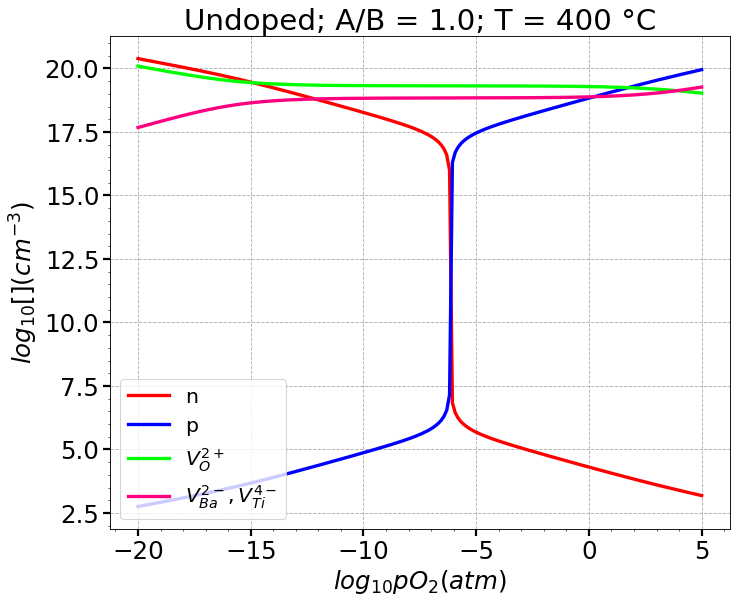

In [31]:
"""
[4] undoped & A/B = 1.000 & low T quenched

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-]
    where [VBa2-] = [VTi4-] with full Schottky reaction & ionic defects (VO2 & VBa2 & VTi4) frozen-in from high T eq to low T quenched state
"""
ratio = 1.000

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*CVBa2_un_1000e[i] + 4*CVTi4_un_1000e[i] - (KiQ/x) - 2*CVO2_un_1000e[i])
    sol1 = brentq(f,1E-20,1E30, maxiter=200)
    
    n_un_1000q[i] = np.array(sol1).astype(np.float64)
    p_un_1000q[i] = KiQ/n_un_1000q[i]
    CVO2_un_1000q[i] = CVO2_un_1000e[i]
    CVTi4_un_1000q[i] = CVTi4_un_1000e[i]
    CVBa2_un_1000q[i] = CVBa2_un_1000e[i]

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Undoped; A/B = {ratio}; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_un_1000q),c =[255/255, 0/255, 0/255], label=r'n', linewidth=3)
ax1.plot(np.log10(a),np.log10(p_un_1000q), c =[0/255, 0/255, 255/255], label = r'p', linewidth=3)
ax1.plot(np.log10(a),np.log10(CVO2_un_1000q),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$', linewidth=3)
ax1.plot(np.log10(a),np.log10(CVBa2_un_1000q), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}, V_{Ti}^{4-}$', linewidth=3)
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
# ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'undoped & A/B = {ratio} & T = {TQC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_un_1000q[154]:.2e}\n'
    f'p = {p_un_1000q[154]:.2e}\n'
    f'[VO2+] = {CVO2_un_1000q[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_un_1000q[154]:.2e}\n'
    f'[VTi4-] = {CVTi4_un_1000q[154]:.2e}'
)

undoped & A/B = 0.999 & T = 800 °C
at pO2 ~ 0.21 atm
n = 3.79e+12
p = 4.84e+18
[VO2+] = 2.09e+19
[VBa2-] = 1.81e+19
[VTi4-] = 2.60e+18


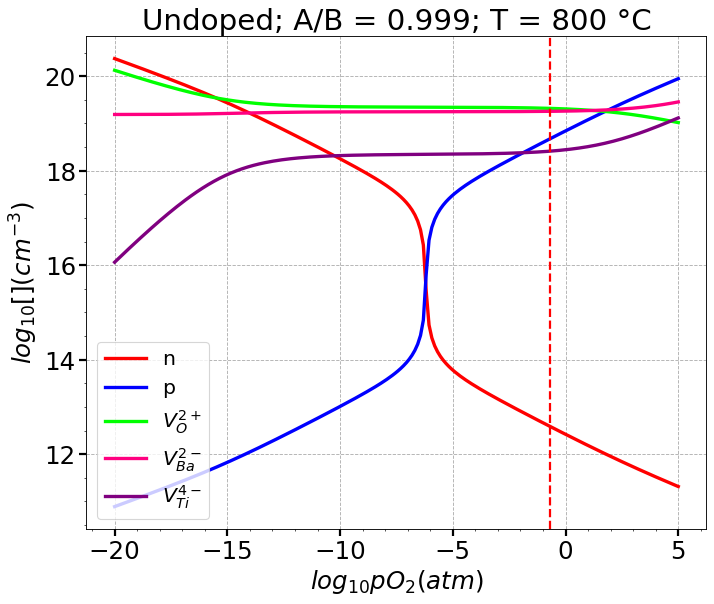

In [46]:
"""
[5] undoped & A/B = 0.999 & low T quenched

Charge neutrality condition: p + 2[VO2+] = n + 2[VBa2-] + 4[VTi4-]
    where [VBa2-] = [VTi4-] + (1 - ratio)*1.55E22 cm-3 & ionic defects (VO2 & VBa2 & VTi4) frozen-in from high T eq to low T quenched state
"""
ratio = 0.999

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + 2*CVBa2_un_999e[i] + 4*CVTi4_un_999e[i] - (KiQ/x) - 2*CVO2_un_999e[i])
    sol1 = brentq(f,1E-20,1E30, maxiter=200)
    
    n_un_999q[i] = np.array(sol1).astype(np.float64)
    p_un_999q[i] = KiQ/n_un_999q[i]
    CVO2_un_999q[i] = CVO2_un_999e[i]
    CVTi4_un_999q[i] = CVTi4_un_999e[i]
    CVBa2_un_999q[i] = CVBa2_un_999e[i]

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Undoped; A/B = {ratio}; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_un_999q),c =[255/255, 0/255, 0/255], label=r'n', linewidth=3)
ax1.plot(np.log10(a),np.log10(p_un_999q), c =[0/255, 0/255, 255/255], label = r'p', linewidth=3)
ax1.plot(np.log10(a),np.log10(CVO2_un_999q),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$', linewidth=3)
ax1.plot(np.log10(a),np.log10(CVBa2_un_999q), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}$', linewidth=3)
ax1.plot(np.log10(a),np.log10(CVTi4_un_999q), c =[128/255, 0/255, 128/255], label = r'$V_{Ti}^{4-}$', linewidth=3)
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'undoped & A/B = {ratio} & T = {TQC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_un_999q[154]:.2e}\n'
    f'p = {p_un_999q[154]:.2e}\n'
    f'[VO2+] = {CVO2_un_999q[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_un_999q[154]:.2e}\n'
    f'[VTi4-] = {CVTi4_un_999q[154]:.2e}'
)